# 05 — Explainability v2: ECGUNet v14 vs TCNEncDec v6
# PTB-XL ECG Forecasting  (4.9 s → 4.9 s)
# Techniques: Gradient×Input, Temporal Importance, Lead Importance,
#             Occlusion Sensitivity, Prediction Overlay, Error Decomposition


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter1d
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 120, 'savefig.dpi': 150,
})
print(f"Device: {DEVICE}")
print("✅ Imports ready")


Device: cpu
✅ Imports ready


In [2]:
# CELL 2 — PATHS & CONFIG
SAVE_DIR = os.path.join('..', 'data', 'processed')
CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')
FIG_DIR  = os.path.join('..', 'reports', 'figures', 'explainability')
os.makedirs(FIG_DIR, exist_ok=True)

CNN_CKPT = os.path.join(CKPT_DIR, 'ECG_CNN_v14_best.pt')
TCN_CKPT = os.path.join(CKPT_DIR, 'TCN_v6_best.pt')

print(f"CNN ckpt: {CNN_CKPT}  exists={os.path.exists(CNN_CKPT)}")
print(f"TCN ckpt: {TCN_CKPT}  exists={os.path.exists(TCN_CKPT)}")

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

FS = cfg['sampling_rate']; INPUT_LEN = cfg['input_len']
HORIZON = cfg['horizon'];  N_LEADS = cfg['n_leads']
LEAD_NAMES = cfg['lead_names']

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')
    plt.show(); print(f"✅ Saved → {name}")

print(f"Input {INPUT_LEN}@{FS}Hz  Horizon {HORIZON}  Leads {N_LEADS}")
print("✅ Config loaded")


CNN ckpt: ../reports/checkpoints/ECG_CNN_v14_best.pt  exists=True
TCN ckpt: ../reports/checkpoints/TCN_v6_best.pt  exists=False
Input 490@100Hz  Horizon 490  Leads 12
✅ Config loaded


In [3]:
# CELL 3 — LOAD TEST DATA
X_test = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

N_XAI = min(100, len(X_test))
X_xai = X_test[:N_XAI]   # (N, INPUT_LEN, 12)
y_xai = y_test[:N_XAI]   # (N, HORIZON,   12)

print(f"X_xai : {X_xai.shape}   y_xai : {y_xai.shape}")
print("✅ Data loaded")


X_xai : (100, 490, 12)   y_xai : (100, 490, 12)
✅ Data loaded


In [4]:
# CELL 4 — MODEL DEFINITIONS  (exact match to training notebooks)

class ConvBNGELU(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, d=1):
        super().__init__()
        pad = ((k-1)*d)//2
        self.net = nn.Sequential(
            nn.Conv1d(in_c, out_c, k, stride=s, dilation=d, padding=pad, bias=False),
            nn.GroupNorm(min(8, out_c), out_c), nn.GELU())
    def forward(self, x): return self.net(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c, dilation=1):
        super().__init__()
        self.conv1 = ConvBNGELU(in_c, out_c, k=5, d=dilation)
        self.conv2 = ConvBNGELU(out_c, out_c, k=5, d=dilation)
        self.down  = nn.Conv1d(out_c, out_c, 2, stride=2, bias=False)
        self.drop  = nn.Dropout(0.10)
    def forward(self, x):
        x = self.conv2(self.conv1(x)); skip = x
        return self.drop(self.down(x)), skip

class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up    = nn.ConvTranspose1d(in_c, in_c, 2, stride=2)
        self.conv1 = ConvBNGELU(in_c + skip_c, out_c, k=5)
        self.conv2 = ConvBNGELU(out_c, out_c, k=5)
        self.drop  = nn.Dropout(0.10)
    def forward(self, x, skip):
        x = self.up(x)
        diff = skip.shape[-1] - x.shape[-1]
        if diff > 0: x = F.pad(x, (0, diff))
        elif diff < 0: x = x[..., :skip.shape[-1]]
        return self.drop(self.conv2(self.conv1(torch.cat([x, skip], dim=1))))

class ECGUNet(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__()
        self.horizon = horizon
        self.enc1=EncoderBlock(n_leads, 64,  dilation=1)
        self.enc2=EncoderBlock(64,      128, dilation=2)
        self.enc3=EncoderBlock(128,     256, dilation=4)
        self.enc4=EncoderBlock(256,     256, dilation=8)
        self.bottleneck_lstm = nn.LSTM(256, 128, 2, batch_first=True, bidirectional=True, dropout=dropout)
        self.bottleneck_proj = ConvBNGELU(256, 256, k=1)
        self.dec4=DecoderBlock(256,256,256); self.dec3=DecoderBlock(256,256,128)
        self.dec2=DecoderBlock(128,128, 64); self.dec1=DecoderBlock( 64, 64, 32)
        self.out_conv = nn.Conv1d(32, n_leads, 1)
    def forward(self, x):
        x,s1=self.enc1(x); x,s2=self.enc2(x); x,s3=self.enc3(x); x,s4=self.enc4(x)
        lo,_=self.bottleneck_lstm(x.permute(0,2,1))
        x=self.bottleneck_proj(lo.permute(0,2,1))
        x=self.dec4(x,s4); x=self.dec3(x,s3); x=self.dec2(x,s2); x=self.dec1(x,s1)
        x=x[...,:self.horizon]
        return self.out_conv(x).permute(0,2,1)

class Chomp1d(nn.Module):
    def __init__(self, s): super().__init__(); self.chomp_size = s
    def forward(self, x): return x[:,:,:-self.chomp_size] if self.chomp_size > 0 else x

class TemporalBlock(nn.Module):
    def __init__(self, ni, no, ks=5, dilation=1, dropout=0.10):
        super().__init__()
        p = (ks-1)*dilation
        self.conv1=nn.Conv1d(ni,no,ks,padding=p,dilation=dilation,bias=False)
        self.chomp1=Chomp1d(p); self.gn1=nn.GroupNorm(min(8,no),no)
        self.conv2=nn.Conv1d(no,no,ks,padding=p,dilation=dilation,bias=False)
        self.chomp2=Chomp1d(p); self.gn2=nn.GroupNorm(min(8,no),no)
        self.drop=nn.Dropout(dropout); self.act=nn.GELU()
        self.skip=nn.Conv1d(ni,no,1,bias=False) if ni!=no else None
    def forward(self,x):
        o=self.drop(self.act(self.gn1(self.chomp1(self.conv1(x)))))
        o=self.drop(self.act(self.gn2(self.chomp2(self.conv2(o)))))
        return self.act(o+(x if self.skip is None else self.skip(x)))

class TCNEncoderDecoder(nn.Module):
    def __init__(self, n_leads=12, horizon=490, dropout=0.10):
        super().__init__(); self.horizon=horizon
        self.enc1=TemporalBlock(n_leads,64, dilation=1,dropout=dropout)
        self.enc2=TemporalBlock(64,    128, dilation=2,dropout=dropout)
        self.enc3=TemporalBlock(128,   256, dilation=4,dropout=dropout)
        self.enc4=TemporalBlock(256,   256, dilation=8,dropout=dropout)
        self.bottleneck=nn.Sequential(nn.Conv1d(256,256,1,bias=False),nn.GroupNorm(8,256),nn.GELU(),nn.Dropout(dropout))
        self.dec1=nn.Sequential(nn.Conv1d(256+256,256,3,padding=1,bias=False),nn.GroupNorm(8,256),nn.GELU(),nn.Dropout(dropout))
        self.dec2=nn.Sequential(nn.Conv1d(256,128,3,padding=1,bias=False),nn.GroupNorm(8,128),nn.GELU(),nn.Dropout(dropout))
        self.dec3=nn.Sequential(nn.Conv1d(128+128,64,3,padding=1,bias=False),nn.GroupNorm(8,64),nn.GELU(),nn.Dropout(dropout))
        self.out_conv=nn.Conv1d(64,n_leads,1)
    def _interp(self,x,size): return F.interpolate(x,size=size,mode='linear',align_corners=False)
    def forward(self,x):
        T=self.horizon
        s1=self.enc1(x);s2=self.enc2(s1);s3=self.enc3(s2);s4=self.enc4(s3)
        btn=self.bottleneck(s4)
        d=self._interp(btn,T); d=self.dec1(torch.cat([d,self._interp(s4,T)],dim=1))
        d=self._interp(d,T);   d=self.dec2(d)
        d=self._interp(d,T);   d=self.dec3(torch.cat([d,self._interp(s2,T)],dim=1))
        return self.out_conv(d).permute(0,2,1)

print("✅ ECGUNet + TCNEncoderDecoder defined")


✅ ECGUNet + TCNEncoderDecoder defined


In [5]:
# CELL 5 — LOAD WEIGHTS
def load_ckpt(model, path, name):
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        sd   = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
        # Strip _orig_mod. prefix from torch.compile() saves
        sd   = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
        model.load_state_dict(sd)
        n = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"✅ {name} loaded  ({n:,} params)")
    else:
        print(f"⚠  {name} checkpoint NOT found at {path}")
        print(f"   ↳ Download from Google Drive and place in: {CKPT_DIR}/")
    model.eval(); return model

cnn_model = ECGUNet(n_leads=N_LEADS, horizon=HORIZON).to(DEVICE)
tcn_model = TCNEncoderDecoder(n_leads=N_LEADS, horizon=HORIZON).to(DEVICE)

cnn_model = load_ckpt(cnn_model, CNN_CKPT, 'ECGUNet v14')
tcn_model = load_ckpt(tcn_model, TCN_CKPT, 'TCNEncDec v6')

✅ ECGUNet v14 loaded  (4,283,340 params)
⚠  TCNEncDec v6 checkpoint NOT found at ../reports/checkpoints/TCN_v6_best.pt
   ↳ Download from Google Drive and place in: ../reports/checkpoints/


In [6]:
# CELL 6 — GRADIENT × INPUT ATTRIBUTION
# Grad×Input highlights which (time, lead) input features steer the forecast.
# sign: positive → pushed prediction toward ground truth.

def gradient_x_input(model, X_np, y_np, batch=20):
    """Returns attr (N, INPUT_LEN, 12) and preds (N, HORIZON, 12)."""
    model.eval()
    attrs_all, preds_all = [], []
    for i in range(0, len(X_np), batch):
        X_b = torch.tensor(X_np[i:i+batch], dtype=torch.float32)   # (B, T, 12)
        y_b = torch.tensor(y_np[i:i+batch], dtype=torch.float32).to(DEVICE)
        X_in = X_b.permute(0, 2, 1).to(DEVICE).requires_grad_(True)   # (B,12,T)
        pred = model(X_in)
        loss = F.mse_loss(pred, y_b)
        loss.backward()
        grad  = X_in.grad.detach()          # (B, 12, T)
        attr  = (grad * X_in.detach())      # Grad×Input
        attrs_all.append(attr.permute(0,2,1).cpu().numpy())   # → (B,T,12)
        preds_all.append(pred.detach().cpu().numpy())
    return np.concatenate(attrs_all), np.concatenate(preds_all)

print("Computing Grad×Input for ECGUNet v14 …")
cnn_attr, cnn_preds = gradient_x_input(cnn_model, X_xai, y_xai)
print(f"  attr: {cnn_attr.shape}  preds: {cnn_preds.shape}")

print("Computing Grad×Input for TCNEncDec v6 …")
tcn_attr, tcn_preds = gradient_x_input(tcn_model, X_xai, y_xai)
print(f"  attr: {tcn_attr.shape}  preds: {tcn_preds.shape}")
print("✅ Attributions ready")


Computing Grad×Input for ECGUNet v14 …
  attr: (100, 490, 12)  preds: (100, 490, 12)
Computing Grad×Input for TCNEncDec v6 …
  attr: (100, 490, 12)  preds: (100, 490, 12)
✅ Attributions ready


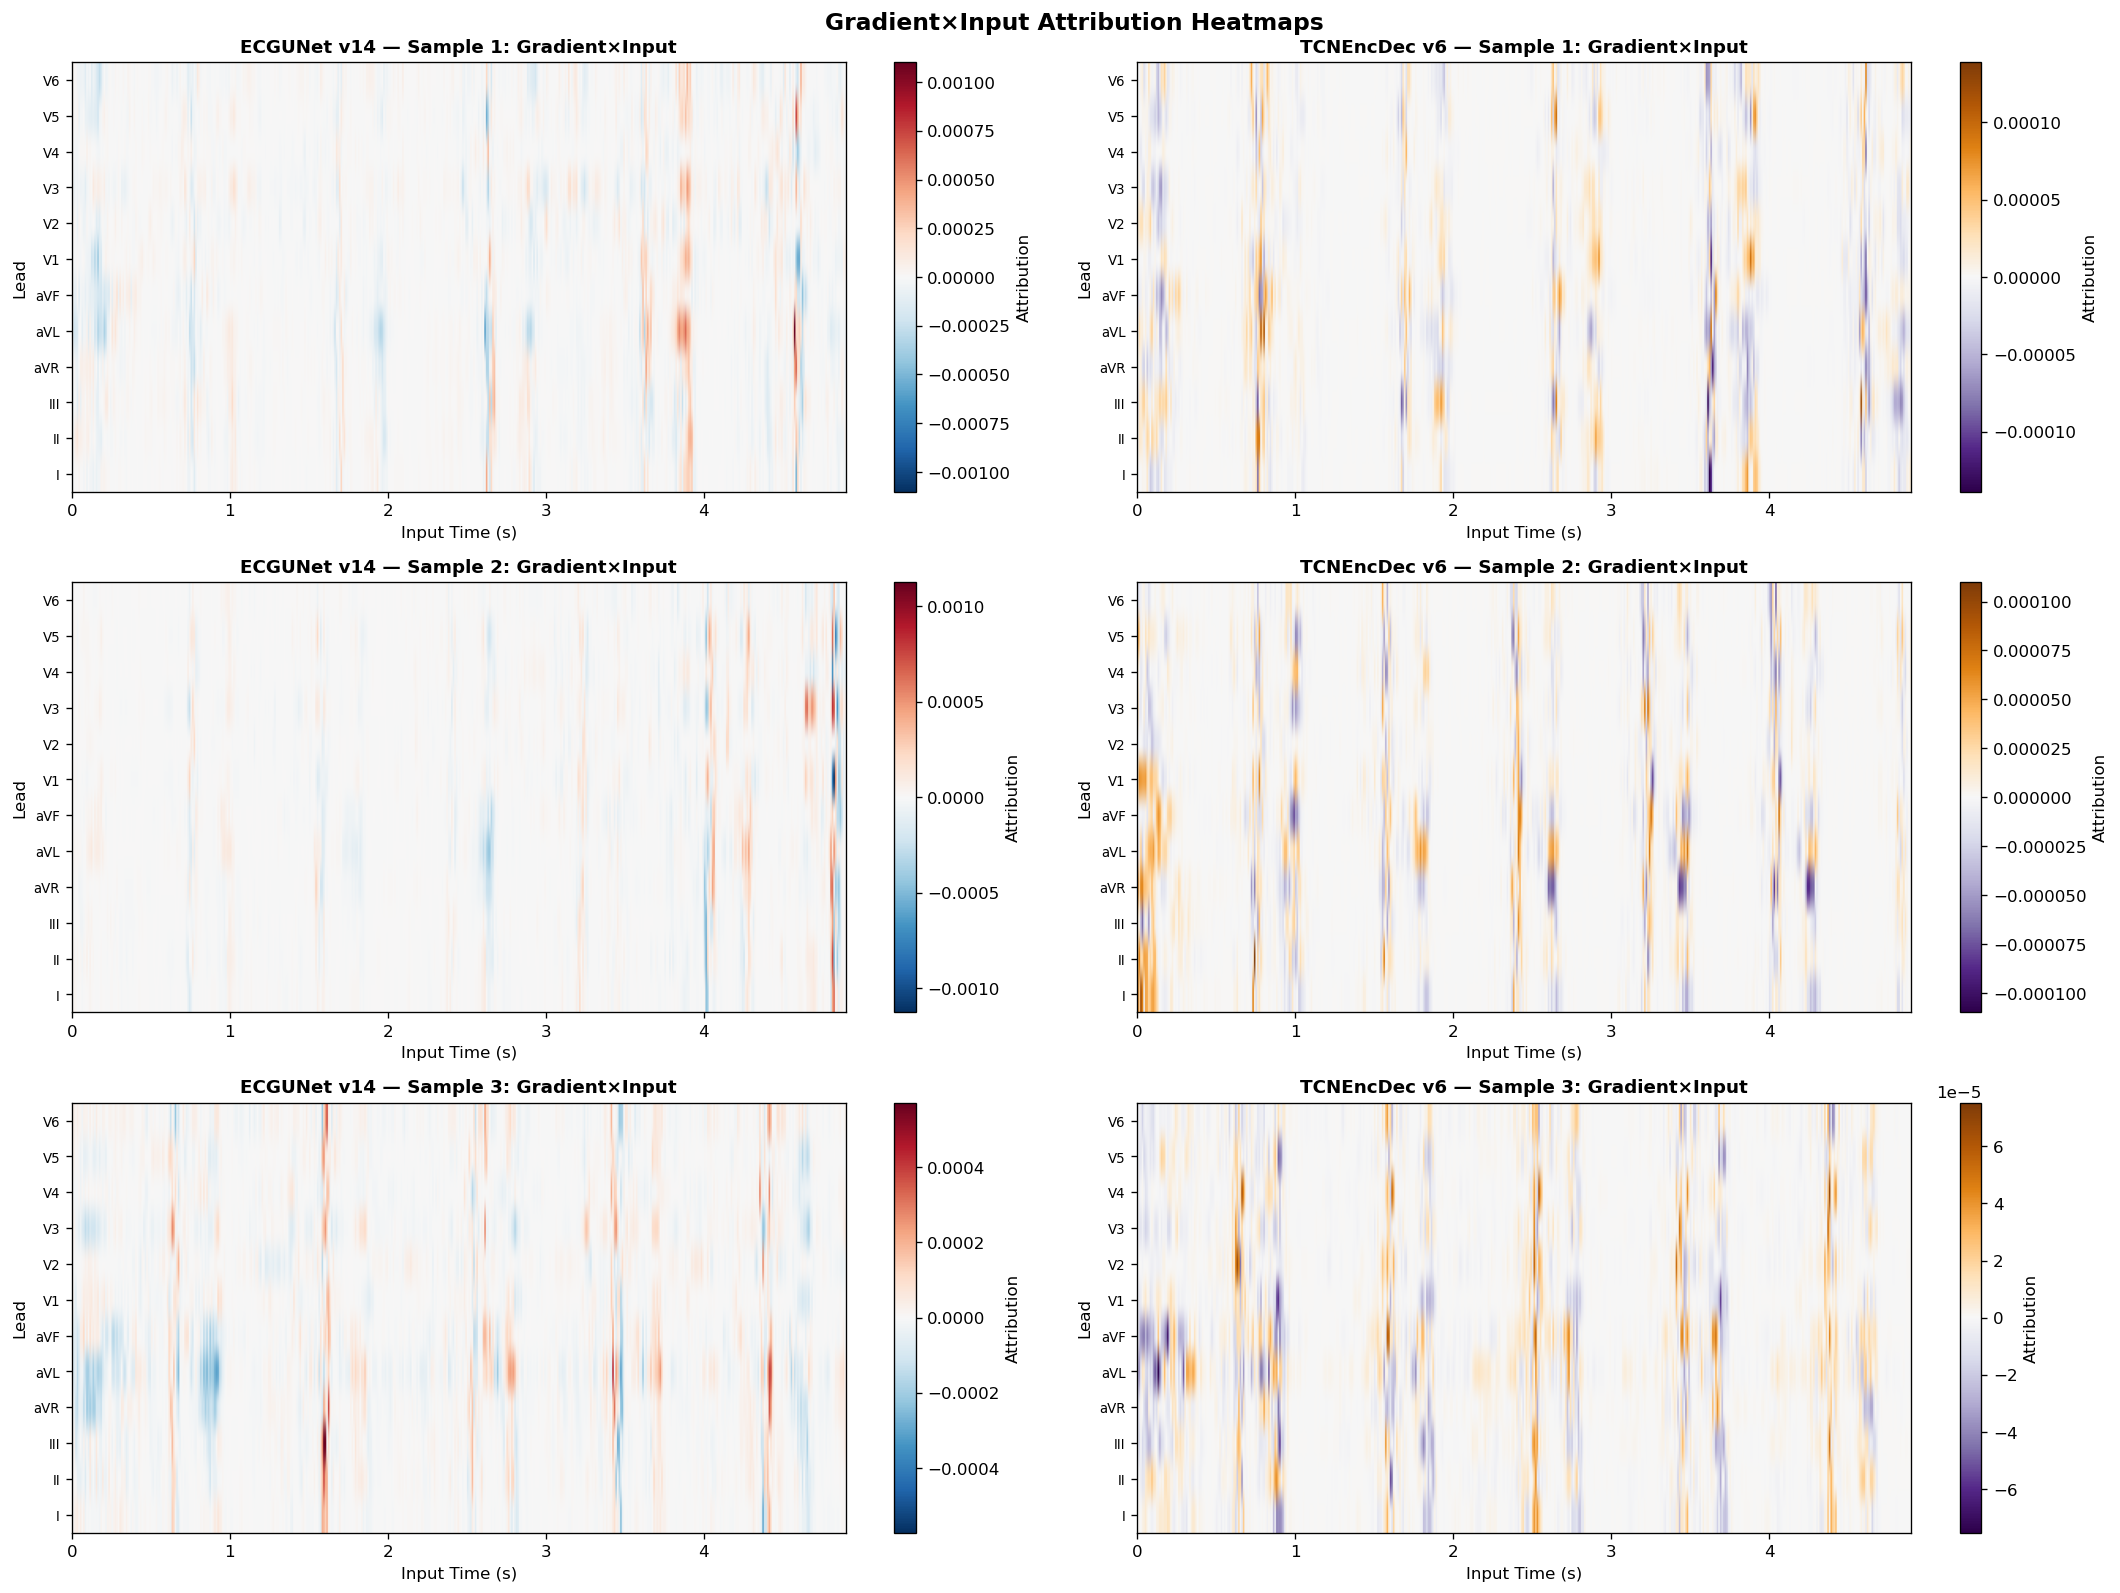

✅ Saved → 01_attribution_heatmaps.png


In [7]:
# CELL 7 — ATTRIBUTION HEATMAPS (3 samples × 2 models)
n_viz = 3
t_in  = np.arange(INPUT_LEN) / FS

fig, axes = plt.subplots(n_viz, 2, figsize=(18, 4.5*n_viz))
for idx in range(n_viz):
    for col, (name, attr, cmap) in enumerate([
        ('ECGUNet v14',  cnn_attr, 'RdBu_r'),
        ('TCNEncDec v6', tcn_attr, 'PuOr_r'),
    ]):
        ax   = axes[idx, col]
        data = attr[idx].T   # (12, T)
        vmax = max(abs(data.min()), abs(data.max())) + 1e-8
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(data, aspect='auto', cmap=cmap, norm=norm,
                         extent=[0, INPUT_LEN/FS, -0.5, N_LEADS-0.5])
        ax.set_yticks(range(N_LEADS)); ax.set_yticklabels(LEAD_NAMES, fontsize=8)
        ax.set_xlabel('Input Time (s)'); ax.set_ylabel('Lead')
        ax.set_title(f'{name} — Sample {idx+1}: Gradient×Input', fontweight='bold', fontsize=11)
        plt.colorbar(im, ax=ax, label='Attribution')

plt.suptitle('Gradient×Input Attribution Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('01_attribution_heatmaps.png')


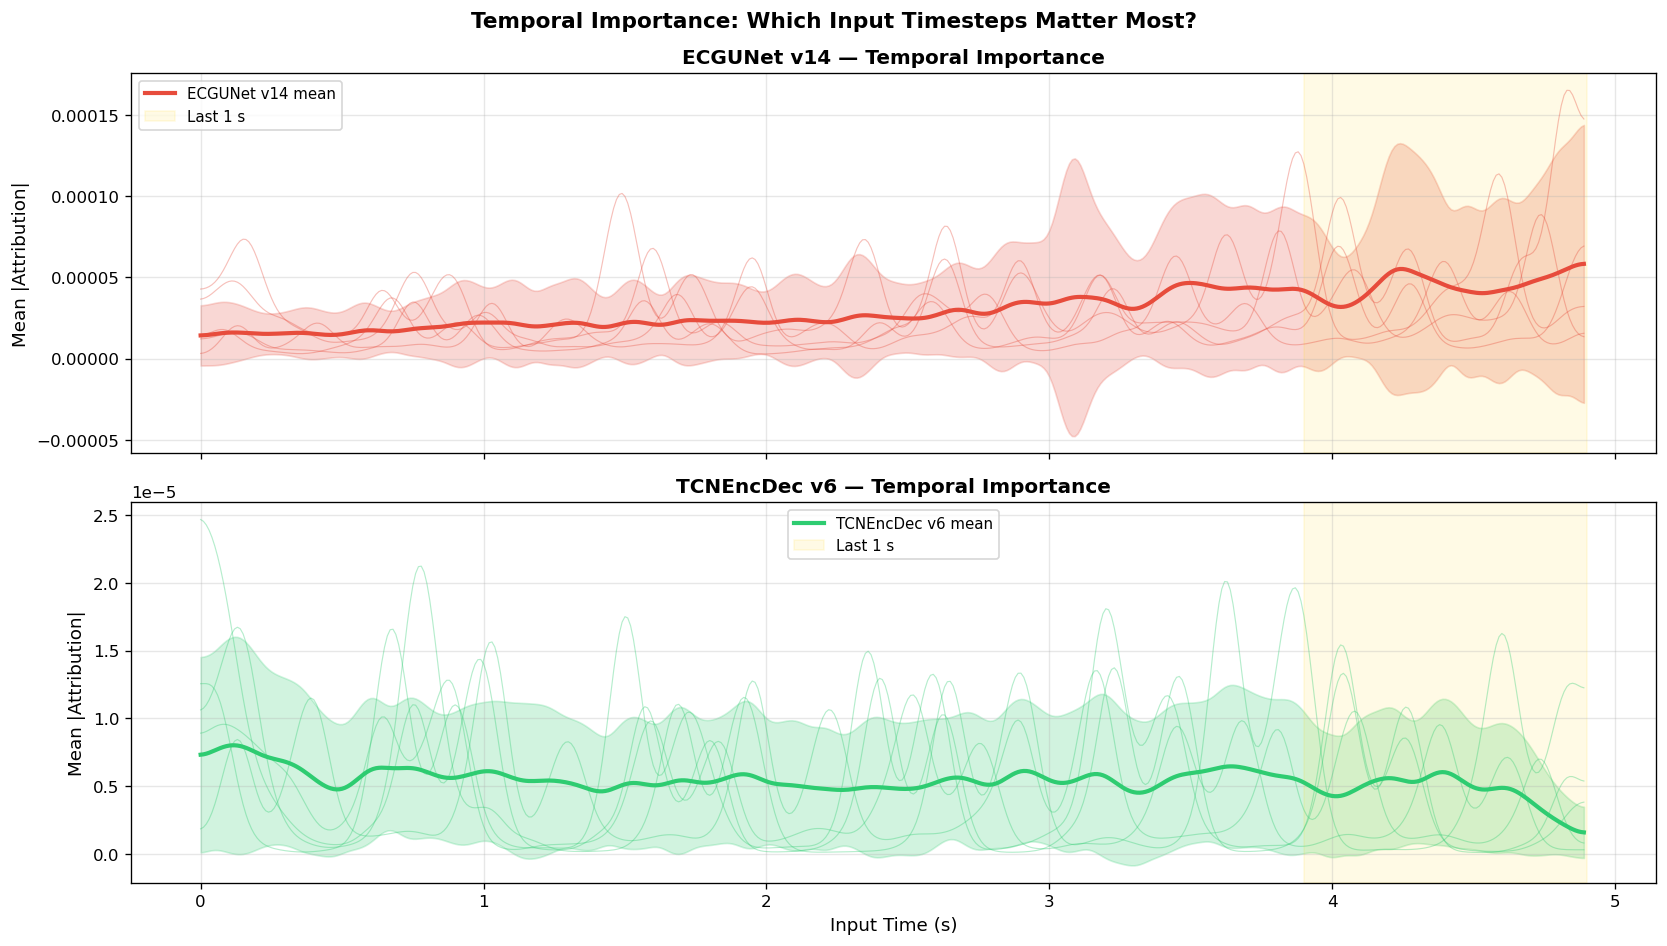

✅ Saved → 02_temporal_importance.png


In [8]:
# CELL 8 — TEMPORAL IMPORTANCE  (which input time window matters most)
wave_time_imp = np.abs(cnn_attr).mean(axis=2)   # (N, T)
tcn_time_imp  = np.abs(tcn_attr).mean(axis=2)
t_in = np.arange(INPUT_LEN) / FS

wave_smooth = np.array([gaussian_filter1d(r, sigma=5) for r in wave_time_imp])
tcn_smooth  = np.array([gaussian_filter1d(r, sigma=5) for r in tcn_time_imp])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, smooth, name, color in [
    (axes[0], wave_smooth, 'ECGUNet v14',  '#e74c3c'),
    (axes[1], tcn_smooth,  'TCNEncDec v6', '#2ecc71'),
]:
    mean = smooth.mean(0); std = smooth.std(0)
    ax.fill_between(t_in, mean-std, mean+std, alpha=0.22, color=color)
    ax.plot(t_in, mean, color=color, lw=2.5, label=f'{name} mean')
    for i in range(min(5, len(smooth))):
        ax.plot(t_in, smooth[i], lw=0.7, alpha=0.35, color=color)
    ax.axvspan((INPUT_LEN-100)/FS, INPUT_LEN/FS, alpha=0.10, color='gold', label='Last 1 s')
    ax.set_ylabel('Mean |Attribution|', fontsize=11)
    ax.set_title(f'{name} — Temporal Importance', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Input Time (s)', fontsize=11)
plt.suptitle('Temporal Importance: Which Input Timesteps Matter Most?', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('02_temporal_importance.png')


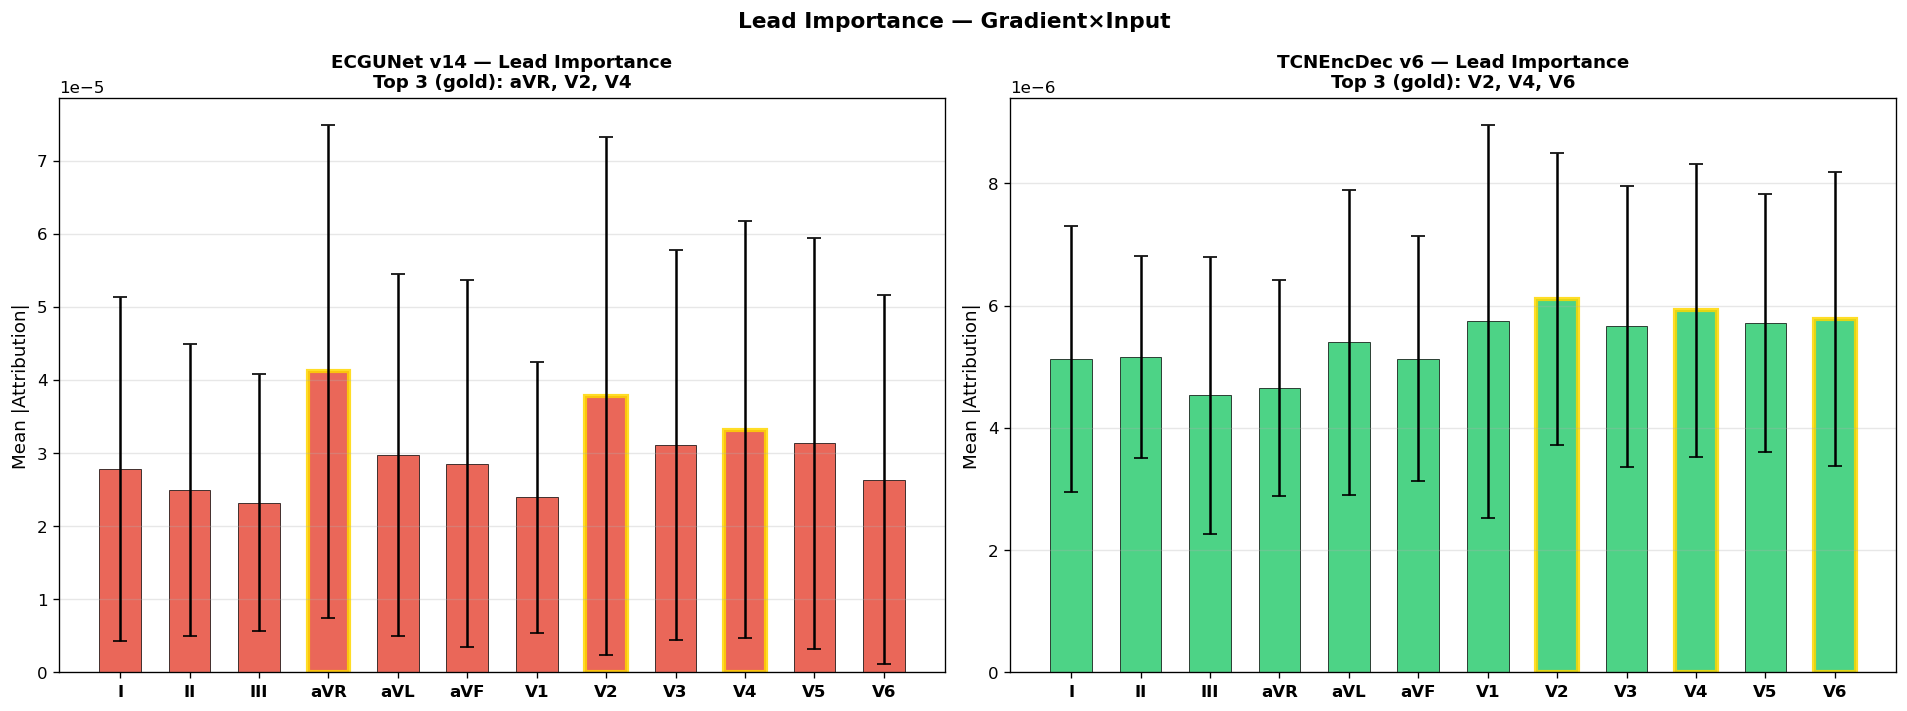

✅ Saved → 03_lead_importance.png
ECGUNet top leads  : ['aVR', 'V2', 'V4']
TCNEncDec top leads: ['V2', 'V4', 'V6']


In [9]:
# CELL 9 — LEAD IMPORTANCE (gradient-based)
cnn_lead_imp = np.abs(cnn_attr).mean(axis=1)   # (N, 12)
tcn_lead_imp = np.abs(tcn_attr).mean(axis=1)

cnn_lm = cnn_lead_imp.mean(0); cnn_ls = cnn_lead_imp.std(0)
tcn_lm = tcn_lead_imp.mean(0); tcn_ls = tcn_lead_imp.std(0)

x = np.arange(N_LEADS)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mean, std, name, color in [
    (axes[0], cnn_lm, cnn_ls, 'ECGUNet v14',  '#e74c3c'),
    (axes[1], tcn_lm, tcn_ls, 'TCNEncDec v6', '#2ecc71'),
]:
    bars = ax.bar(x, mean, 0.6, color=color, alpha=0.85, edgecolor='black', lw=0.5, yerr=std, capsize=4)
    top3 = np.argsort(mean)[-3:]
    for i in top3: bars[i].set_edgecolor('gold'); bars[i].set_linewidth(2.5)
    ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean |Attribution|', fontsize=11)
    top_names = [LEAD_NAMES[i] for i in np.argsort(mean)[-3:][::-1]]
    ax.set_title(f'{name} — Lead Importance\nTop 3 (gold): {", ".join(top_names)}',
                 fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Lead Importance — Gradient×Input', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('03_lead_importance.png')
print(f"ECGUNet top leads  : {[LEAD_NAMES[i] for i in np.argsort(cnn_lm)[-3:][::-1]]}")
print(f"TCNEncDec top leads: {[LEAD_NAMES[i] for i in np.argsort(tcn_lm)[-3:][::-1]]}")


Occlusion sensitivity — ECGUNet v14 …
  baseline MSE = 1.40658
Occlusion sensitivity — TCNEncDec v6 …
  baseline MSE = 1.61046


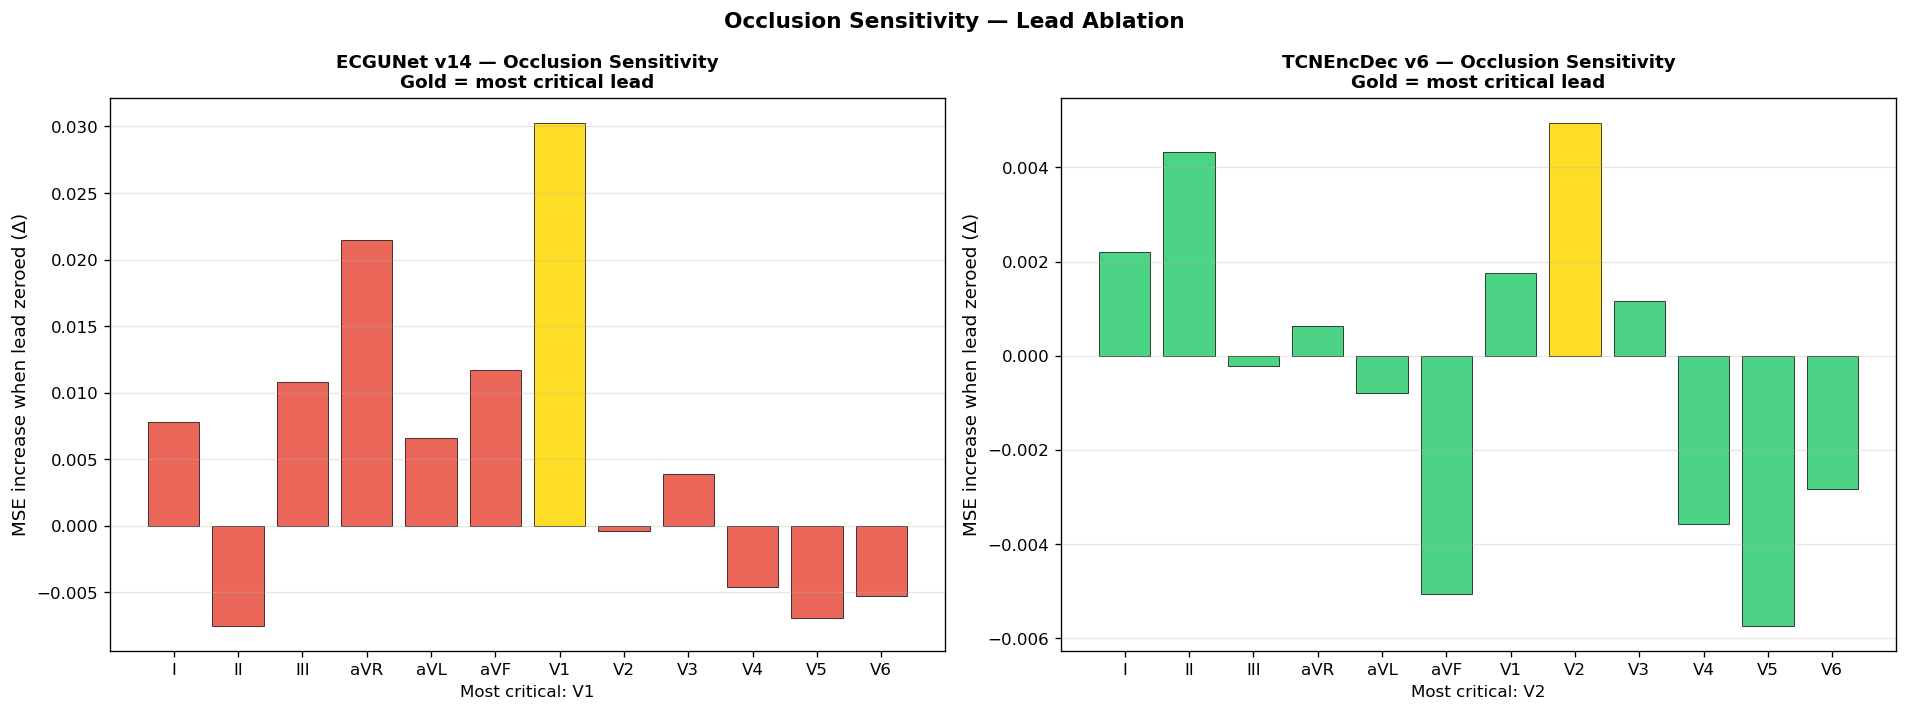

✅ Saved → 04_occlusion_sensitivity.png
ECGUNet most critical lead  : V1
TCNEncDec most critical lead: V2


In [10]:
# CELL 10 — OCCLUSION SENSITIVITY  (zero out one lead at a time)
def occlusion_sensitivity(model, X_np, y_np, batch=32):
    """Returns per-lead MSE-delta array (12,).  Input X_np: (N, T, 12)."""
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds_base = []
        for i in range(0,len(X_t),batch):
            xb = X_t[i:i+batch].permute(0,2,1).to(DEVICE)
            preds_base.append(model(xb).cpu())
        baseline_mse = F.mse_loss(torch.cat(preds_base), torch.tensor(y_np)).item()
    deltas = []
    for li in range(N_LEADS):
        X_occ = X_t.clone(); X_occ[:, :, li] = 0.0   # channel-last zero-out
        with torch.no_grad():
            preds_occ = []
            for i in range(0,len(X_occ),batch):
                xb = X_occ[i:i+batch].permute(0,2,1).to(DEVICE)
                preds_occ.append(model(xb).cpu())
        occ_mse = F.mse_loss(torch.cat(preds_occ), torch.tensor(y_np)).item()
        deltas.append(occ_mse - baseline_mse)
    return np.array(deltas), baseline_mse

print("Occlusion sensitivity — ECGUNet v14 …")
cnn_occ, cnn_base = occlusion_sensitivity(cnn_model, X_xai, y_xai)
print(f"  baseline MSE = {cnn_base:.5f}")

print("Occlusion sensitivity — TCNEncDec v6 …")
tcn_occ, tcn_base = occlusion_sensitivity(tcn_model, X_xai, y_xai)
print(f"  baseline MSE = {tcn_base:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, occ, name, color in [
    (axes[0], cnn_occ, 'ECGUNet v14',  '#e74c3c'),
    (axes[1], tcn_occ, 'TCNEncDec v6', '#2ecc71'),
]:
    cols = ['gold' if v == occ.max() else color for v in occ]
    ax.bar(LEAD_NAMES, occ, color=cols, alpha=0.85, edgecolor='black', lw=0.5)
    ax.set_ylabel('MSE increase when lead zeroed (Δ)', fontsize=11)
    ax.set_title(f'{name} — Occlusion Sensitivity\nGold = most critical lead', fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlabel(f'Most critical: {LEAD_NAMES[np.argmax(occ)]}', fontsize=10)

plt.suptitle('Occlusion Sensitivity — Lead Ablation', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('04_occlusion_sensitivity.png')
print(f"ECGUNet most critical lead  : {LEAD_NAMES[np.argmax(cnn_occ)]}")
print(f"TCNEncDec most critical lead: {LEAD_NAMES[np.argmax(tcn_occ)]}")


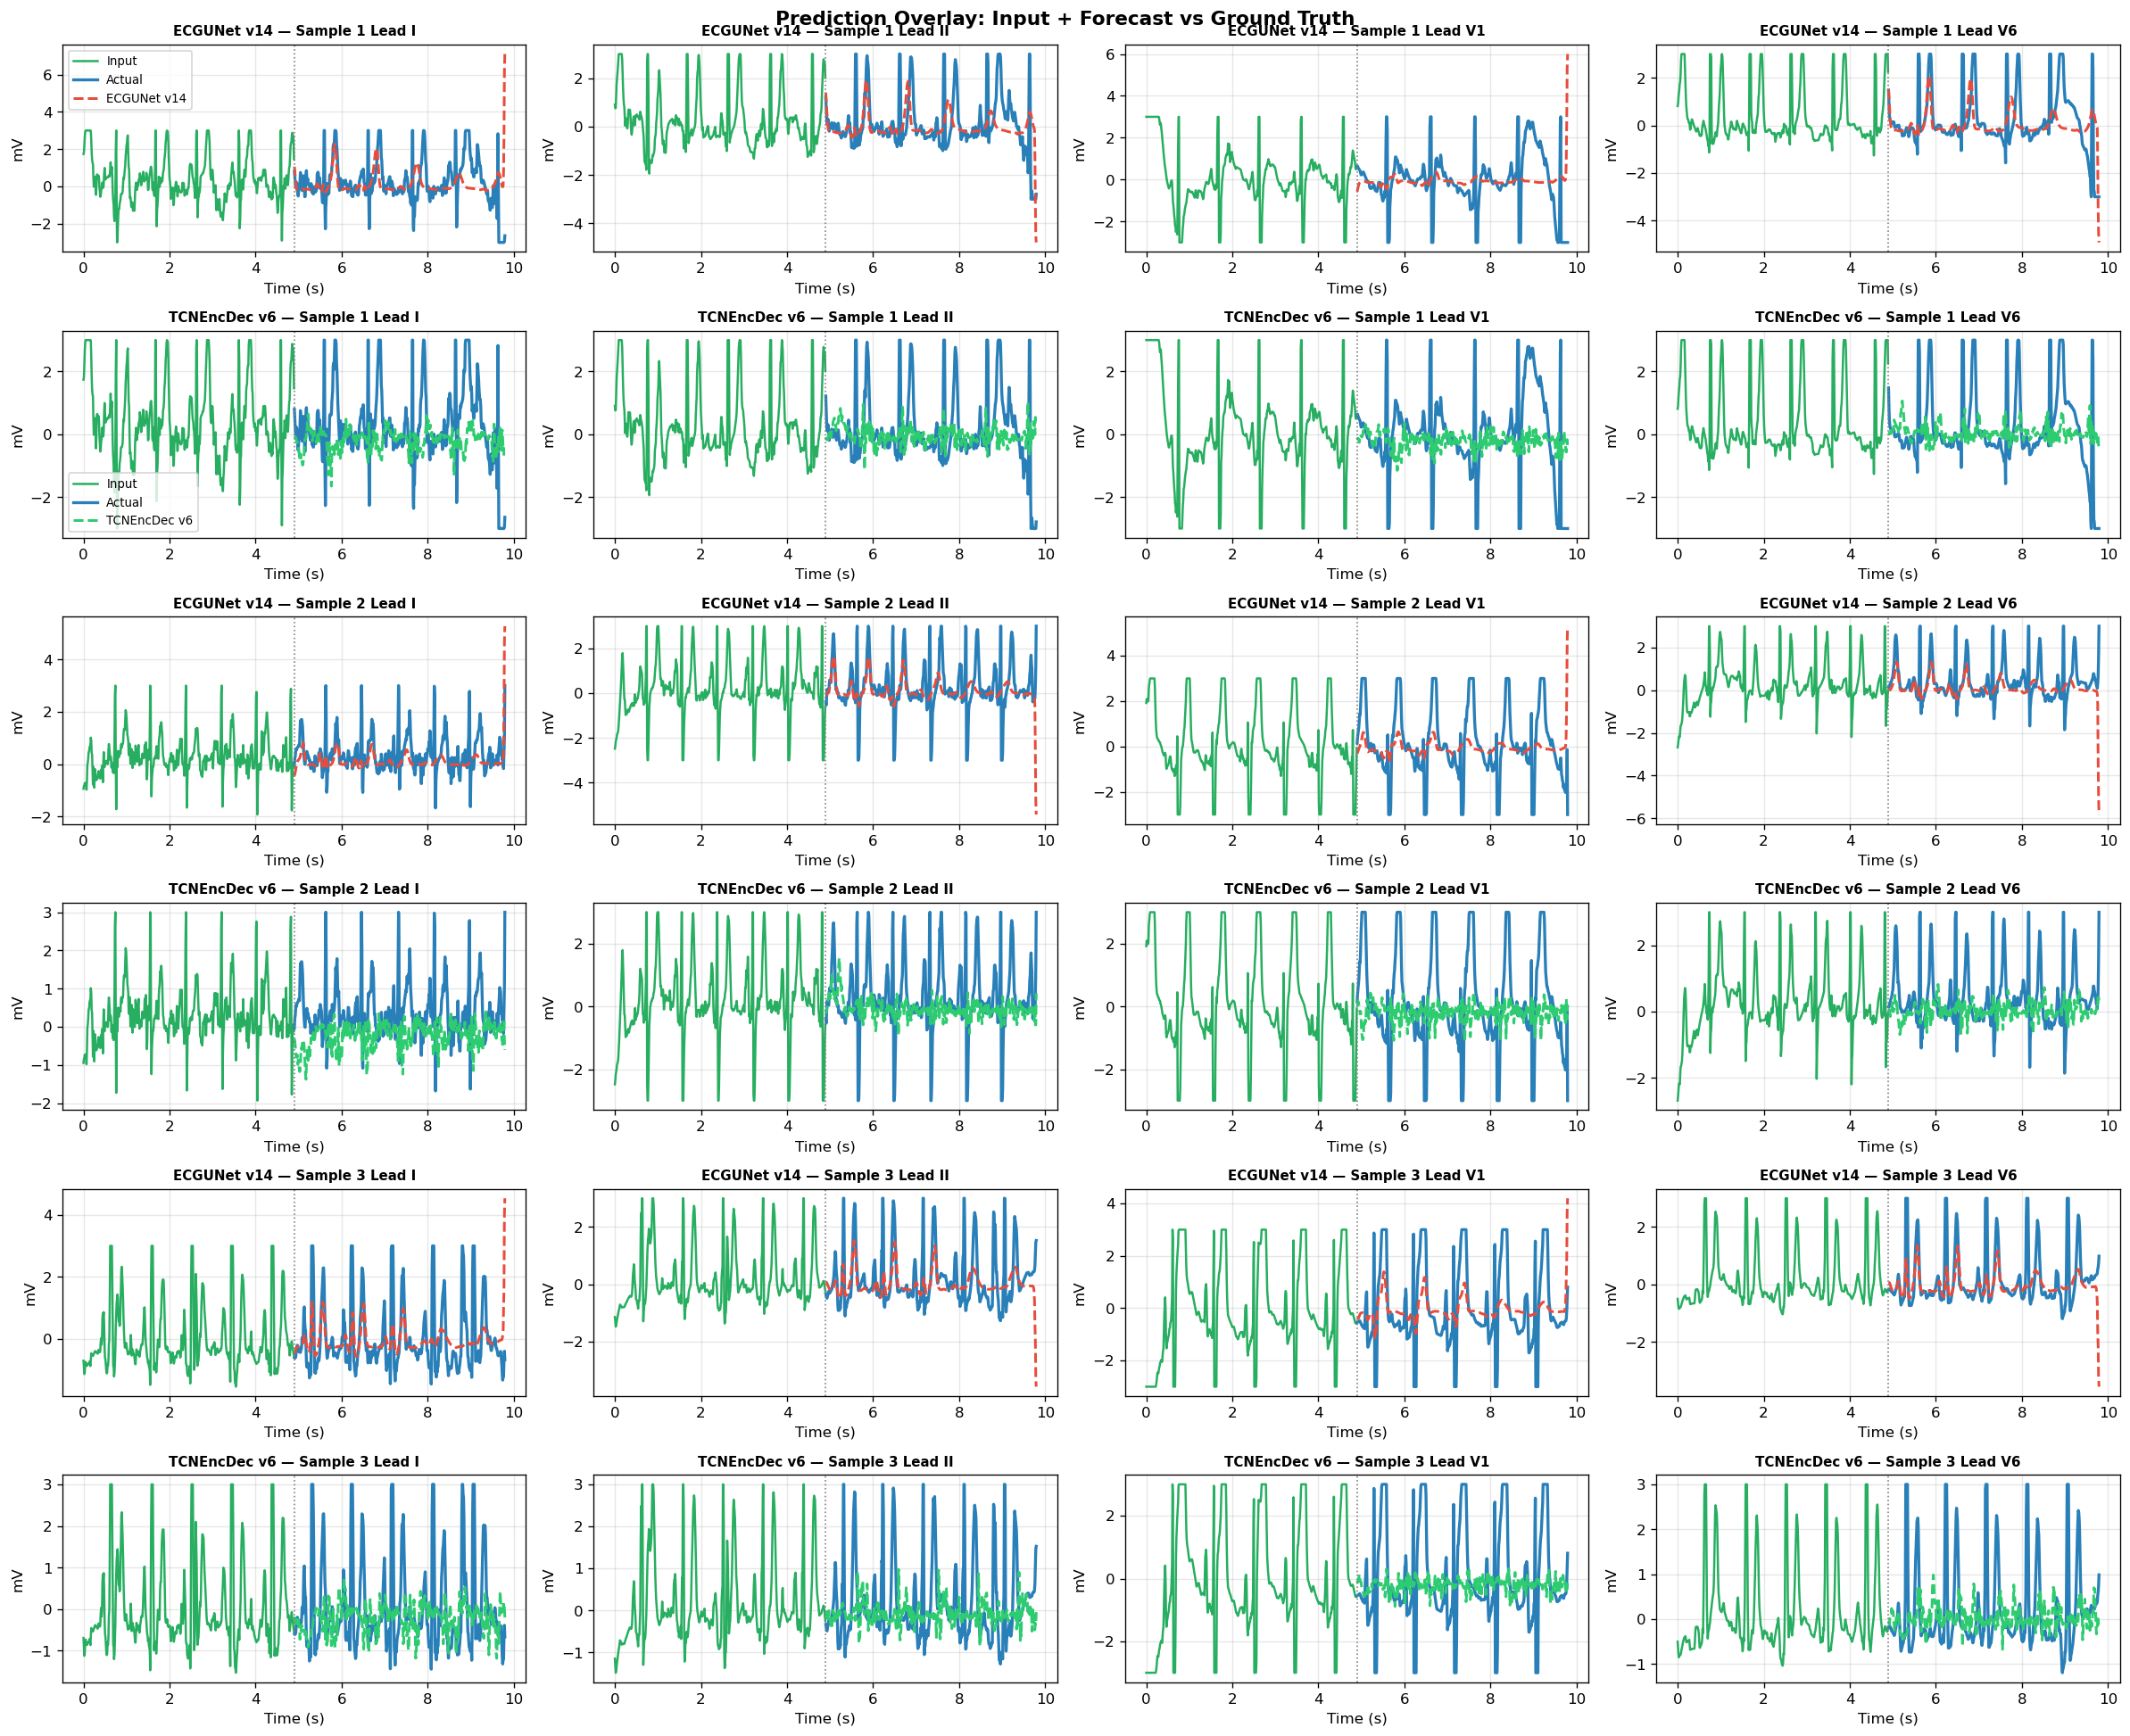

✅ Saved → 05_prediction_overlay.png


In [11]:
# CELL 11 — PREDICTION OVERLAY (3 samples, 4 leads)
n_show     = 3
leads_show = [0, 1, 6, 11]
t_in  = np.arange(INPUT_LEN) / FS
t_out = np.arange(HORIZON)   / FS + INPUT_LEN/FS

fig, axes = plt.subplots(n_show*2, len(leads_show), figsize=(20, 5.5*n_show))
for row in range(n_show):
    for col, li in enumerate(leads_show):
        x_sig  = X_xai[row, :, li]
        y_true = y_xai[row, :, li]
        for r_off, (name, preds, color) in enumerate([
            ('ECGUNet v14',  cnn_preds, '#e74c3c'),
            ('TCNEncDec v6', tcn_preds, '#2ecc71'),
        ]):
            ax = axes[row*2 + r_off, col]
            ax.plot(t_in,  x_sig,           color='#27ae60', lw=1.5, label='Input')
            ax.plot(t_out, y_true,           color='#2980b9', lw=2,   label='Actual', ls='-')
            ax.plot(t_out, preds[row, :, li],color=color,    lw=1.8, label=name,   ls='--')
            ax.axvline(INPUT_LEN/FS, color='grey', lw=1, ls=':')
            ax.set_title(f'{name} — Sample {row+1} Lead {LEAD_NAMES[li]}',
                         fontweight='bold', fontsize=9)
            ax.set_xlabel('Time (s)'); ax.set_ylabel('mV')
            ax.grid(alpha=0.3)
            if row == 0 and col == 0: ax.legend(fontsize=8)

plt.suptitle('Prediction Overlay: Input + Forecast vs Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('05_prediction_overlay.png')


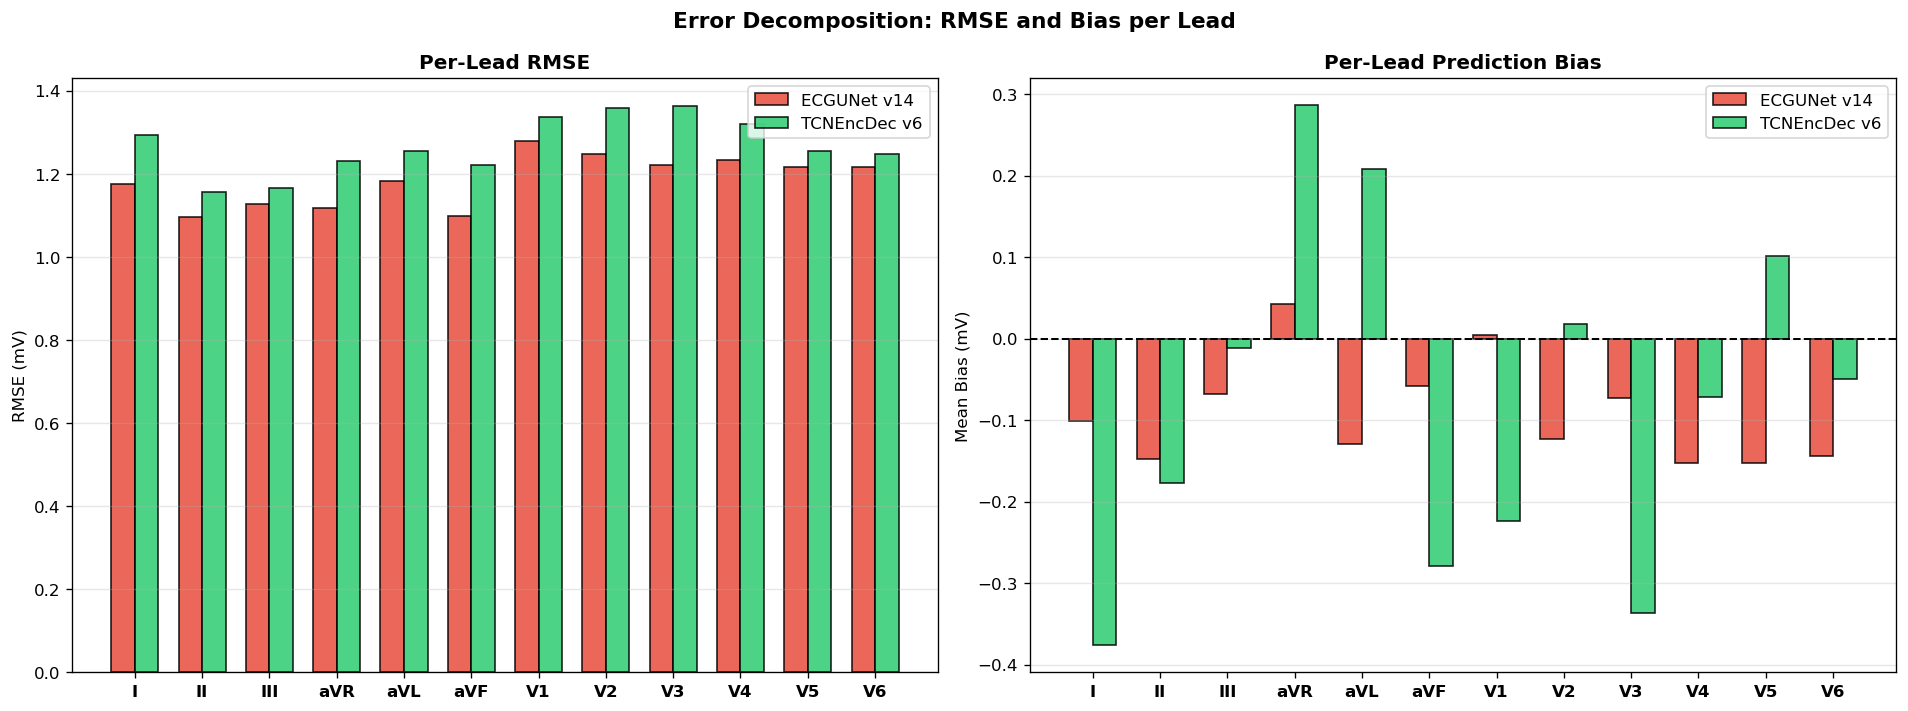

✅ Saved → 06_error_decomposition.png


In [12]:
# CELL 12 — ERROR DECOMPOSITION (per lead RMSE and bias)
cnn_err = cnn_preds - y_xai[:len(cnn_preds)]
tcn_err = tcn_preds - y_xai[:len(tcn_preds)]

cnn_rmse_lead = np.sqrt((cnn_err**2).mean(axis=(0,1)))   # (12,)
tcn_rmse_lead = np.sqrt((tcn_err**2).mean(axis=(0,1)))
cnn_bias_lead = cnn_err.mean(axis=(0,1))
tcn_bias_lead = tcn_err.mean(axis=(0,1))

x = np.arange(N_LEADS); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.bar(x-w/2, cnn_rmse_lead, w, label='ECGUNet v14',  color='#e74c3c', alpha=0.85, edgecolor='black')
ax.bar(x+w/2, tcn_rmse_lead, w, label='TCNEncDec v6', color='#2ecc71', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
ax.set_ylabel('RMSE (mV)'); ax.set_title('Per-Lead RMSE', fontweight='bold', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x-w/2, cnn_bias_lead, w, label='ECGUNet v14',  color='#e74c3c', alpha=0.85, edgecolor='black')
ax.bar(x+w/2, tcn_bias_lead, w, label='TCNEncDec v6', color='#2ecc71', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
ax.set_ylabel('Mean Bias (mV)'); ax.set_title('Per-Lead Prediction Bias', fontweight='bold', fontsize=12)
ax.axhline(0, color='black', lw=1.2, ls='--')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Error Decomposition: RMSE and Bias per Lead', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('06_error_decomposition.png')


In [13]:
# CELL 13 — SUMMARY TABLE
import pandas as pd
from IPython.display import display

cnn_overall_rmse = float(np.sqrt(((cnn_preds - y_xai[:len(cnn_preds)])**2).mean()))
tcn_overall_rmse = float(np.sqrt(((tcn_preds - y_xai[:len(tcn_preds)])**2).mean()))
cnn_overall_mae  = float(np.abs(cnn_preds - y_xai[:len(cnn_preds)]).mean())
tcn_overall_mae  = float(np.abs(tcn_preds - y_xai[:len(tcn_preds)]).mean())

df = pd.DataFrame({
    'Model':           ['ECGUNet v14 (CNN-BiLSTM U-Net)', 'TCNEncDec v6'],
    'RMSE (mV)':       [f'{cnn_overall_rmse:.5f}', f'{tcn_overall_rmse:.5f}'],
    'MAE (mV)':        [f'{cnn_overall_mae:.5f}',  f'{tcn_overall_mae:.5f}'],
    'Top lead (grad)': [LEAD_NAMES[np.argmax(cnn_lm)], LEAD_NAMES[np.argmax(tcn_lm)]],
    'Critical lead':   [LEAD_NAMES[np.argmax(cnn_occ)],LEAD_NAMES[np.argmax(tcn_occ)]],
})
display(df)
print("\n✅ Explainability Notebook v2 complete — figures in", FIG_DIR)


,Model,RMSE (mV),MAE (mV),Top lead (grad),Critical lead
0,ECGUNet v14 (CNN-BiLSTM U-Net),1.18599,0.77350,aVR,V1
1,TCNEncDec v6,1.26904,0.91241,V2,V2



✅ Explainability Notebook v2 complete — figures in ../reports/figures/explainability
